In [40]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [41]:
import pickle
import numpy as np



In [42]:
with open("pose_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)




In [43]:
max_len = 100  

X = pad_sequences(dataset, maxlen=max_len, dtype='float32', padding='post', truncating='post')

print("Dataset shape:", X.shape)  

np.save("pose_dataset.npy", X)

Dataset shape: (81, 100, 132)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense



In [65]:
X = np.load("pose_dataset.npy")
X = X.astype("float32") / 255.0
timesteps, features = X.shape[1], X.shape[2]



In [66]:
X[0]

array([[ 1.8889253e-03,  1.3735591e-03, -1.0600736e-03, ...,
         3.7001220e-03,  1.0074889e-04,  3.8162789e-03],
       [ 1.8916109e-03,  1.3736695e-03, -9.5312652e-04, ...,
         3.6951369e-03,  7.8944446e-05,  3.8159634e-03],
       [ 1.8944691e-03,  1.3742975e-03, -9.5791713e-04, ...,
         3.6891575e-03,  7.8197663e-05,  3.8161038e-03],
       ...,
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
      shape=(100, 132), dtype=float32)

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [68]:
model = Sequential([
    LSTM(128, activation="tanh", input_shape=(timesteps, features), return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    RepeatVector(timesteps),

    LSTM(128, activation="tanh", return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    TimeDistributed(Dense(64, activation="relu")),
    TimeDistributed(Dense(features, activation="sigmoid"))
])

d:\Tauqeer Work\FYP\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [69]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # smaller lr
    loss="mse",                          # better for reconstruction
    metrics=["mse"]                      # use mse, not accuracy
)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)


In [70]:
history = model.fit(
    X, X,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 276ms/step - loss: 0.2487 - mse: 0.2487 - val_loss: 0.2484 - val_mse: 0.2484
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.2480 - mse: 0.2480 - val_loss: 0.2480 - val_mse: 0.2480
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2470 - mse: 0.2470 - val_loss: 0.2475 - val_mse: 0.2475
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2446 - mse: 0.2446 - val_loss: 0.2469 - val_mse: 0.2469
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2397 - mse: 0.2397 - val_loss: 0.2461 - val_mse: 0.2461
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2289 - mse: 0.2289 - val_loss: 0.2451 - val_mse: 0.2451
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2118 - mse: 0.2118 - val_loss: 0.2432 - val_mse: 0.2432
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1999 - mse: 0.1999 - val_loss: 0.2415 - val_mse: 0.2415
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1862 - mse: 0.1862 -

In [71]:
# Save model
model.save("exercise_autoencoder.h5")

In [22]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# TensorFlow will automatically use GPU if found


Num GPUs Available: 0


In [23]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2229488008569870150
xla_global_id: -1
]


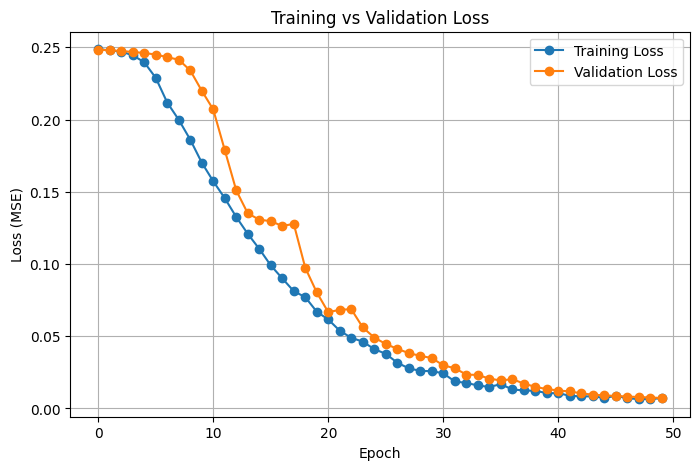

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()